# Investigating a Deployed ML Model via API - Single-Feature Case

- Author: Jaya Srinivas
- Date: 2026-08
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

**Problem (simplified from the example project):** the case example sweeps one
feature *and* builds a two-feature decision grid. This notebook asks one
narrower, easier question instead: holding `bill_length_mm`, `bill_depth_mm`,
and `flipper_length_mm` fixed at the Adelie baseline, can `body_mass_g` alone
shift the predicted species?

Same deployed model, same API contract, same `predict()` / `sweep_feature()`
structure as the example - only the question being asked is smaller.

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07_custom", level="DEBUG")
log_header(LOG, "M07_custom")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-08-09 00:50:15 | INFO | M07_custom | === RUN START ===
2026-08-09 00:50:15 | INFO | M07_custom | project=M07_custom
2026-08-09 00:50:15 | INFO | M07_custom | repo_dir=ml-07-applied
2026-08-09 00:50:15 | INFO | M07_custom | python=3.14.6
2026-08-09 00:50:15 | INFO | M07_custom | os=Darwin 23.6.0
2026-08-09 00:50:15 | INFO | M07_custom | shell=zsh
2026-08-09 00:50:15 | INFO | M07_custom | cwd=notebooks
2026-08-09 00:50:15 | INFO | M07_custom | github_actions=False
2026-08-09 00:50:15 | INFO | M07_custom | Confirming installation:
2026-08-09 00:50:15 | INFO | M07_custom |   python:       3.14.6
2026-08-09 00:50:15 | INFO | M07_custom |   pandas:       3.0.5
2026-08-09 00:50:15 | INFO | M07_custom |   numpy:        2.5.1
2026-08-09 00:50:15 | INFO | M07_custom |   matplotlib:   3.11.1
2026-08-09 00:50:15 | INFO | M07_custom |   requests:     2.34.2
2026-08-09 00:50:15 | INFO | M07_custom | API endpoint: https://ml-penguin-predictor.onrender.com/predict


## Section 2. Baseline Prediction

```text
ANALYST CHOICE
Confirm the API returns the expected species for one known input
before investigating. If this fails, the investigation cannot proceed.
```

In [2]:
# === Section 2. Baseline Prediction ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# Single known Adelie example. This also serves as the fixed baseline
# for the body_mass_g sweep below.
BASE: dict[str, Any] = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181,
    "body_mass_g": 3750,
}
EXPECTED_SPECIES: str = "Adelie"

baseline_result = predict(BASE)
match = "OK" if baseline_result == EXPECTED_SPECIES else "MISMATCH"
LOG.info(f"Baseline: expected={EXPECTED_SPECIES} got={baseline_result} [{match}]")

2026-08-09 00:50:45 | INFO | M07_custom | Baseline: expected=Adelie got=TIMEOUT (server may be sleeping - try again) [MISMATCH]


## Section 3. Single-Feature Investigation: body_mass_g

```text
ANALYST CHOICE
Vary body_mass_g alone, holding every other feature at the Adelie baseline.
Mark the exact value(s) where the predicted species changes.
```

2026-08-09 00:51:10 | INFO | M07_custom | body_mass_g sweep:
2026-08-09 00:51:10 | INFO | M07_custom |  body_mass_g prediction
 2000.000000     Adelie
 2263.157895     Adelie
 2526.315789     Adelie
 2789.473684     Adelie
 3052.631579     Adelie
 3315.789474     Adelie
 3578.947368     Adelie
 3842.105263     Adelie
 4105.263158     Adelie
 4368.421053     Adelie
 4631.578947     Adelie
 4894.736842     Adelie
 5157.894737     Adelie
 5421.052632     Adelie
 5684.210526     Adelie
 5947.368421     Adelie
 6210.526316     Adelie
 6473.684211     Adelie
 6736.842105     Adelie
 7000.000000     Adelie


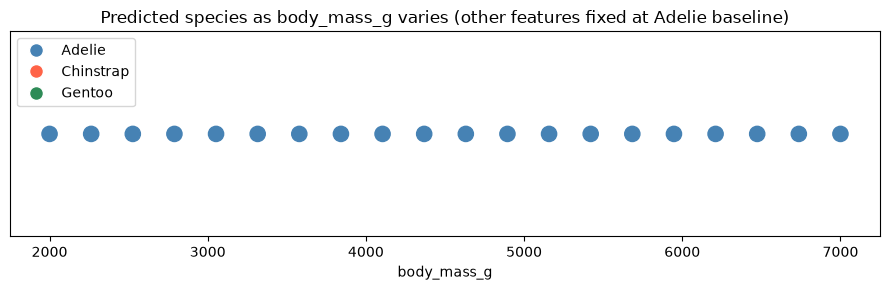

2026-08-09 00:51:10 | INFO | M07_custom | ANALYST CHOICE: body_mass_g never changed the prediction on its own over this range - what does that say about how much this feature matters relative to bill_length_mm (see the example notebook)?


In [3]:
# === Section 3. Single-Feature Investigation: body_mass_g ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Adelie penguins in the training data run roughly 2850g-4775g; sweep a bit
# wider than that range to see if the model ever leaves Adelie.
body_masses = list(np.linspace(2000, 7000, 20))
df_sweep = sweep_feature(BASE, "body_mass_g", body_masses)

LOG.info("body_mass_g sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

# Find where the prediction changes from one species to the next.
transitions = df_sweep[df_sweep["prediction"].ne(df_sweep["prediction"].shift())].iloc[
    1:
]

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["body_mass_g"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("body_mass_g")
plt.yticks([])
plt.title(
    "Predicted species as body_mass_g varies (other features fixed at Adelie baseline)"
)
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]

for _, row in transitions.iterrows():
    plt.axvline(row["body_mass_g"], color="black", linestyle="--", alpha=0.5)
    plt.text(
        row["body_mass_g"],
        1.05,
        f"{row['body_mass_g']:.0f}",
        rotation=90,
        va="bottom",
        ha="right",
        fontsize=8,
    )

plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

if transitions.empty:
    LOG.info(
        "ANALYST CHOICE: body_mass_g never changed the prediction on its own "
        "over this range - what does that say about how much this feature "
        "matters relative to bill_length_mm (see the example notebook)?"
    )
else:
    LOG.info(
        "ANALYST CHOICE: prediction shifted at the body_mass_g value(s) marked "
        "above - does that boundary make sense given what you know about penguins?"
    )

## Section 4. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [4]:
# === Section 4. Summary ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("Investigated feature: body_mass_g (single-feature sweep only)")
    LOG.info("========================")


summarize()

2026-08-09 00:51:10 | INFO | M07_custom | ========================
2026-08-09 00:51:10 | INFO | M07_custom | SUMMARY
2026-08-09 00:51:10 | INFO | M07_custom | ========================
2026-08-09 00:51:10 | INFO | M07_custom | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-08-09 00:51:10 | INFO | M07_custom | Investigated feature: body_mass_g (single-feature sweep only)
2026-08-09 00:51:10 | INFO | M07_custom | ========================
